# Overview
Ten notebook jest przeznaczony do analizy algorytmów redukcji wymiarowości na zbiorze **iris**

https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html

Badamy następujace algorytmy:

- Linear Discriminant Analysis (LDA) (nadzorowane)

- Principal Component Analysis (PCA)

- Kernel PCA

- IsoMap

- UMap

- AutoEncoder

- t-SNE -> głownie do wizualizacji 



Dla kaźdego algorytmu został napisany nastepujący pipeline;
Wybieramy skalowanie danych uźywamy 4 rodzaje:

        StandardScaler()

        RobustScaler()

        MinMaxScaler()

        brak skalowania




0. Dzielimy zbiór na testowy i treningowym 
    X_train, y_train, X_test, y_test = train_test_split(X, 0.8)

1. robimy osobno transform na testowym i treningowym tzn np.:
        X_train_pca = pca.fit_tranform(X_train)
        X_test_pca = pca.transform(X)

2. Będziemy sprawdzać jakość predykcji za pomocą regresji logistycznej oraz K-Nearest-Neighbors

dla róźnej liczby zredukowanych wymiarów

3. sprawdzamy jakość utworzonych klastrów przez KMeans po redukcji wymiarów





In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_iris
from utils.scores import Dataset, DatasetEvaluator
from utils.plots import plot_2d_projection, plot_3d_interactive, plot_2d_projection_comparison

## Loading Datasets

In [114]:
iris = load_iris()
X = iris.data
y = iris.target


evaluators = {'StandardScaler': DatasetEvaluator( Dataset(X, y, 'Iris')),
               'MinMaxScaler': DatasetEvaluator( Dataset(X, y, 'Iris')), 
               'RobustScaler': DatasetEvaluator( Dataset(X, y, 'Iris')), 
               'original': DatasetEvaluator( Dataset(X, y, 'Iris'))}

In [115]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

for name, evaluator in evaluators.items():
    if name != 'original':
        scaler = None
        if name == 'StandardScaler':
            scaler = StandardScaler()
        elif name == 'MinMaxScaler':
            scaler = MinMaxScaler()
        elif name == 'RobustScaler':
            scaler = RobustScaler()
        evaluator.scale(scaler)
        print(evaluator.X_train[:5])



Scaling with StandardScaler...
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]
Scaling with MinMaxScaler...
[[0.08823529 0.66666667 0.         0.04166667]
 [0.41176471 1.         0.0877193  0.125     ]
 [0.70588235 0.45833333 0.59649123 0.54166667]
 [0.14705882 0.58333333 0.10526316 0.04166667]
 [0.02941176 0.5        0.05263158 0.04166667]]
Scaling with RobustScaler...
[[-0.88461538  1.         -0.90277778 -0.73333333]
 [-0.03846154  2.33333333 -0.76388889 -0.6       ]
 [ 0.73076923  0.16666667  0.04166667  0.06666667]
 [-0.73076923  0.66666667 -0.73611111 -0.73333333]
 [-1.03846154  0.33333333 -0.81944444 -0.73333333]]


In [116]:
reductions = {
    'StandardScaler': {},
    'MinMaxScaler': {},
    'RobustScaler': {},
    'original': {}
}

kmeans_results = {}
logistic_regression_results = {}

In [117]:
trustworthiness_results = {}

In [118]:
knn_results = {}

In [119]:
names =[]

# LDA

Dla LDA wymiary po redukcji muszą być mneijsze równe niź liczba klas y -1

Dlatego redukcja tylko do 2D

In [120]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]]
[[0.08823529 0.66666667 0.         0.04166667]
 [0.41176471 1.         0.0877193  0.125     ]]
[[-0.88461538  1.         -0.90277778 -0.73333333]
 [-0.03846154  2.33333333 -0.76388889 -0.6       ]]
[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]]


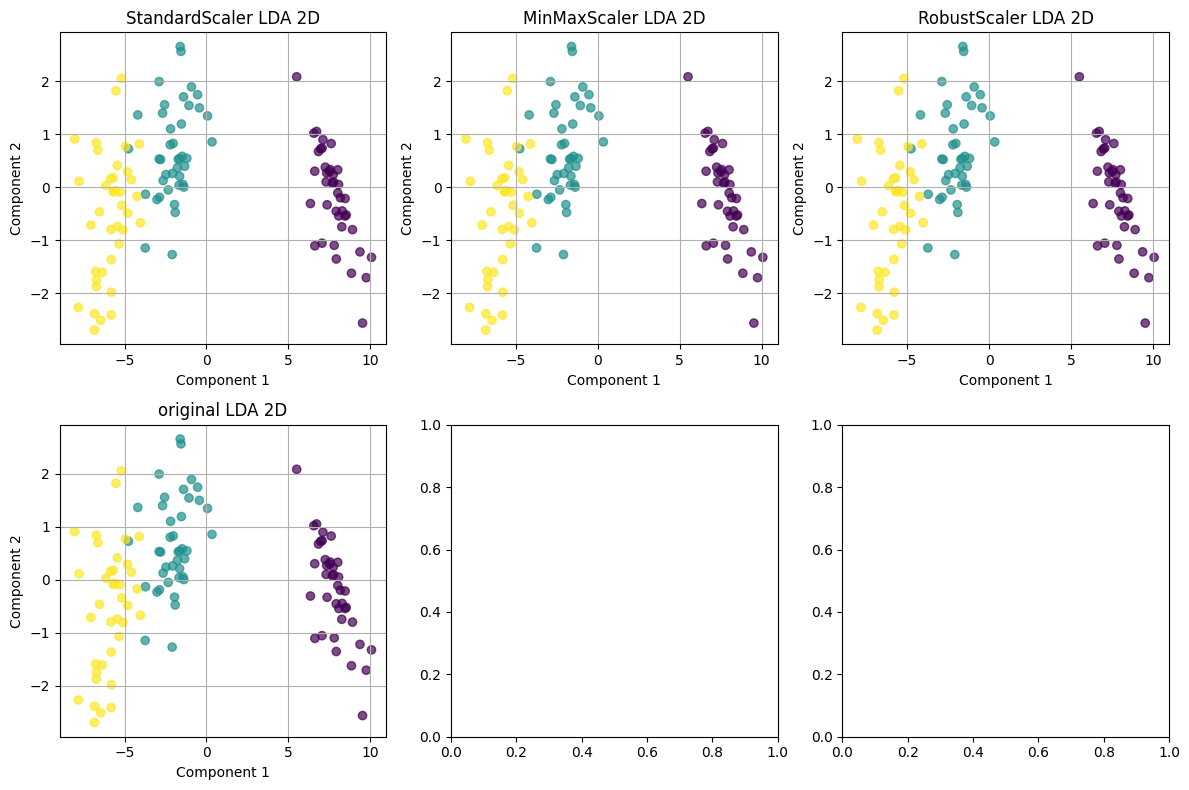

In [121]:

for name, evaluator in evaluators.items():
    LDA_model_2d = LinearDiscriminantAnalysis(n_components=2)
    print(evaluator.X_train[:2])
    X_train_2d = LDA_model_2d.fit_transform(evaluator.X_train, evaluator.y_train)
    X_test_2d = LDA_model_2d.transform(evaluator.X_test)
    reductions[name]['LDA_2d'] = (X_train_2d, X_test_2d)

plot_2d_projection_comparison([(reductions[name]['LDA_2d'][0], f"{name} LDA 2D") for name in reductions], y=evaluator.y_train)


In [122]:
evaluator = evaluators['StandardScaler']
kmeans_results['LDA_2d'] = evaluator._evaluate_reduction_with_kmeans(*reductions['StandardScaler']['LDA_2d'])
logistic_regression_results['LDA_2d'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions['StandardScaler']['LDA_2d'])
kmeans_results['original'] = evaluator._evaluate_reduction_with_kmeans(evaluator.X_train, evaluator.X_test)
logistic_regression_results['original'] = evaluator.predict_on_reduced_with_logistic_regression(evaluator.X_train, evaluator.X_test)
names.append('LDA_2d')
names.append('original')

In [123]:
from sklearn.manifold import trustworthiness
trustworthiness_results['LDA_2d'] = trustworthiness(evaluator.X_train, reductions['StandardScaler']['LDA_2d'][0], n_neighbors=5)

In [124]:
knn_results['LDA_2d'] = evaluator._evaluate_knn_classification(*reductions['StandardScaler']['LDA_2d'])

# PCA

In [125]:
from sklearn.decomposition import PCA

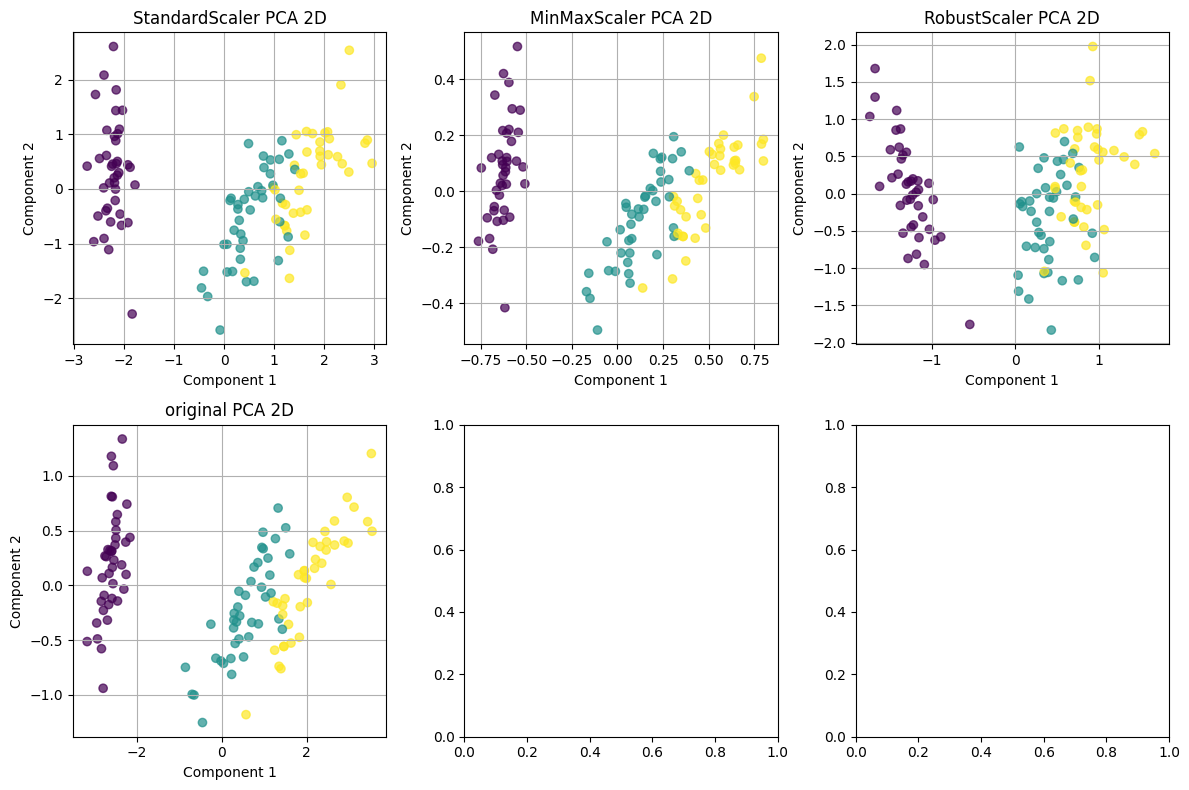

In [126]:
for name, evaluator in evaluators.items():
    PCA_model_2d = PCA(n_components=2)
    X_train_2d = PCA_model_2d.fit_transform(evaluator.X_train)
    X_test_2d = PCA_model_2d.transform(evaluator.X_test)
    reductions[name]['PCA_2d'] = (X_train_2d, X_test_2d)

plot_2d_projection_comparison([(reductions[name]['PCA_2d'][0], f"{name} PCA 2D") for name in reductions], y=evaluator.y_train)


In [127]:
for name, evaluator in evaluators.items():
    kmeans_results[f'PCA_2d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['PCA_2d'])
    logistic_regression_results[f'PCA_2d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['PCA_2d'])
    trustworthiness_results[f'PCA_2d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['PCA_2d'][0], n_neighbors=5)
    knn_results[f'PCA_2d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['PCA_2d'])
    names.append(f'PCA_2d_{name}')


In [128]:
import nbformat
for name, evaluator in evaluators.items():
    PCA_model_3d = PCA(n_components=3)
    X_train_3d = PCA_model_3d.fit_transform(evaluator.X_train)
    X_test_3d = PCA_model_3d.transform(evaluator.X_test)
    reductions[name]['PCA_3d'] = (X_train_3d, X_test_3d)
    names.append(f'PCA_3d_{name}')
    
    plot_3d_interactive(X_train_3d, evaluator.y_train, title=f"{name} PCA 3D")




In [129]:
for name, evaluator in evaluators.items():
    kmeans_results[f'PCA_3d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['PCA_3d'])
    logistic_regression_results[f'PCA_3d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['PCA_3d'])
    trustworthiness_results[f'PCA_3d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['PCA_3d'][0], n_neighbors=5)
    knn_results[f'PCA_3d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['PCA_3d'])



# Kernel PCA

### 2d

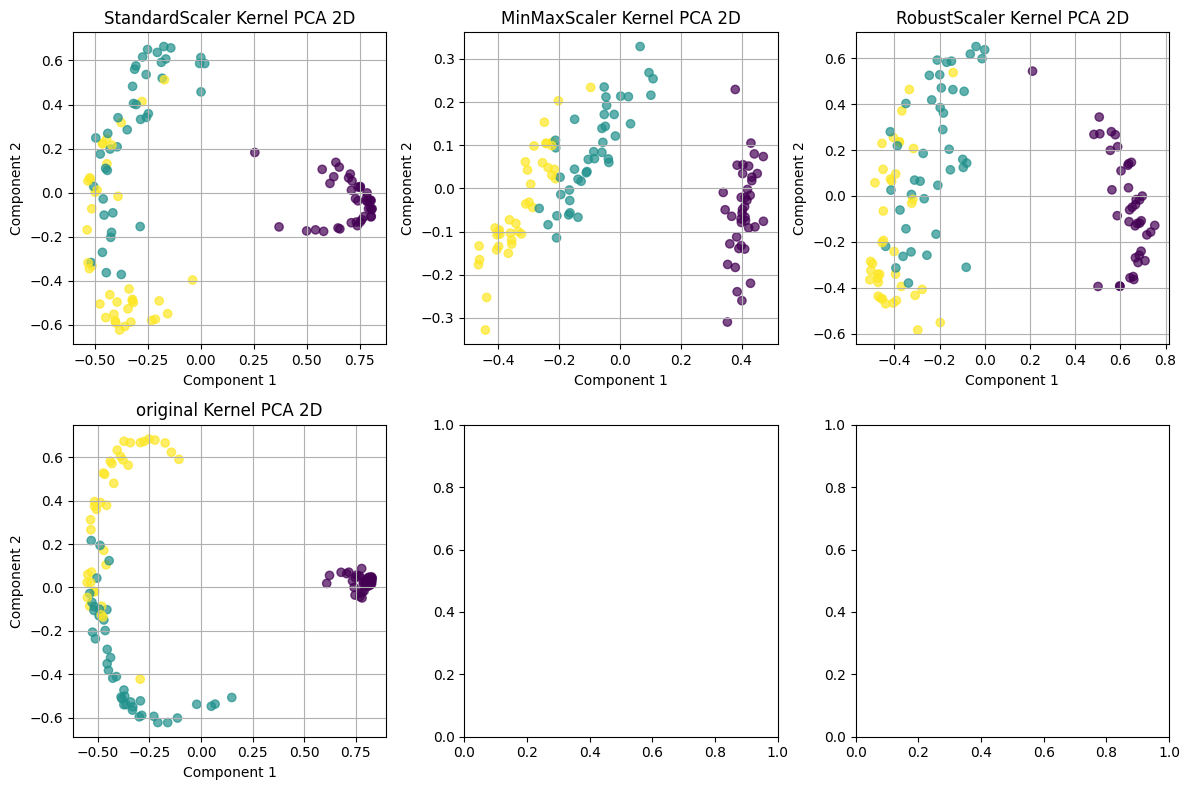

In [16]:
from sklearn.decomposition import  KernelPCA

for name, evaluator in evaluators.items():
    kpca_model_2d = KernelPCA(n_components=2, kernel='rbf')
    X_train_kpca_2d = kpca_model_2d.fit_transform(evaluator.X_train)
    X_test_kpca_2d = kpca_model_2d.transform(evaluator.X_test)
    reductions[name]['KPCA_2d'] = (X_train_kpca_2d, X_test_kpca_2d)

plot_2d_projection_comparison([(reductions[name]['KPCA_2d'][0], f"{name} Kernel PCA 2D") for name in reductions], y=evaluator.y_train)

In [ ]:
for name, evaluator in evaluators.items():
    kmeans_results[f'KPCA_2d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['KPCA_2d'])
    logistic_regression_results[f'KPCA_2d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['KPCA_2d'])
    trustworthiness_results[f'KPCA_2d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['KPCA_2d'][0], n_neighbors=5)
    knn_results[f'KPCA_2d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['KPCA_2d'])    

### 3d

In [130]:
for name, evaluator in evaluators.items():
    kpca_model_3d = KernelPCA(n_components=3, kernel='rbf')
    X_train_kpca_3d = kpca_model_3d.fit_transform(evaluator.X_train)
    X_test_kpca_3d = kpca_model_3d.transform(evaluator.X_test)
    reductions[name]['KPCA_3d'] = (X_train_kpca_3d, X_test_kpca_3d)
    plot_3d_interactive(X_train_kpca_3d, evaluator.y_train, title=f"{name} Kernel PCA 3D")

In [131]:
for name, evaluator in evaluators.items():
    kmeans_results[f'KPCA_3d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['KPCA_3d'])
    logistic_regression_results[f'KPCA_3d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['KPCA_3d'])
    trustworthiness_results[f'KPCA_3d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['KPCA_3d'][0], n_neighbors=5)
    knn_results[f'KPCA_3d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['KPCA_3d'])

## Autoencoder

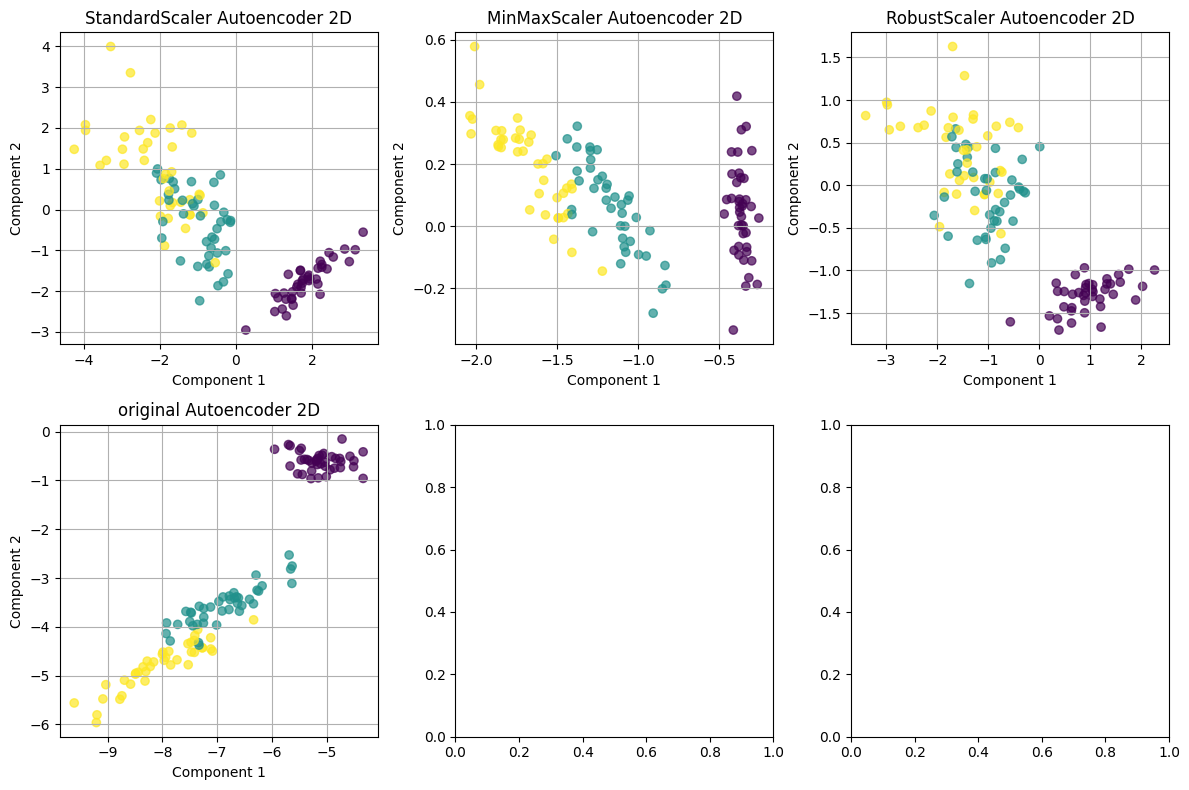

In [132]:
from utils.autoencoder import TorchAutoencoderReducer
for name, evaluator in evaluators.items():
    autoencoder_reducer = TorchAutoencoderReducer(input_dim=evaluator.X_train.shape[1], latent_dim=2)
    X_train_ae_2d = autoencoder_reducer.fit_transform(evaluator.X_train)
    X_test_ae_2d = autoencoder_reducer.transform(evaluator.X_test)
    reductions[name]['AE_2d'] = (X_train_ae_2d, X_test_ae_2d)


plot_2d_projection_comparison([(reductions[name]['AE_2d'][0], f"{name} Autoencoder 2D") for name in reductions], y=evaluator.y_train)


In [133]:
for name, evaluator in evaluators.items():
    kmeans_results[f'AE_2d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['AE_2d'])
    logistic_regression_results[f'AE_2d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['AE_2d'])
    trustworthiness_results[f'AE_2d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['AE_2d'][0], n_neighbors=5)    
    knn_results[f'AE_2d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['AE_2d'])    

In [134]:
for name, evaluator in evaluators.items():
   autonencoder_reducer3d = TorchAutoencoderReducer(input_dim=evaluator.X_train.shape[1], latent_dim=3)
   X_train_ae_3d = autonencoder_reducer3d.fit_transform(evaluator.X_train)
   X_test_ae_3d = autonencoder_reducer3d.transform(evaluator.X_test)
   reductions[name]['AE_3d'] = (X_train_ae_3d, X_test_ae_3d)
   plot_3d_interactive(X_train_ae_3d, evaluator.y_train, title=f"{name} Autoencoder 3D")

In [32]:
for name, evaluator in evaluators.items():
    kmeans_results[f'AE_3d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['AE_3d'])
    logistic_regression_results[f'AE_3d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['AE_3d'])
    trustworthiness_results[f'AE_3d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['AE_3d'][0], n_neighbors=5)
    knn_results[f'AE_3d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['AE_3d'])

# UMAP

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/michalkrajewski/Py

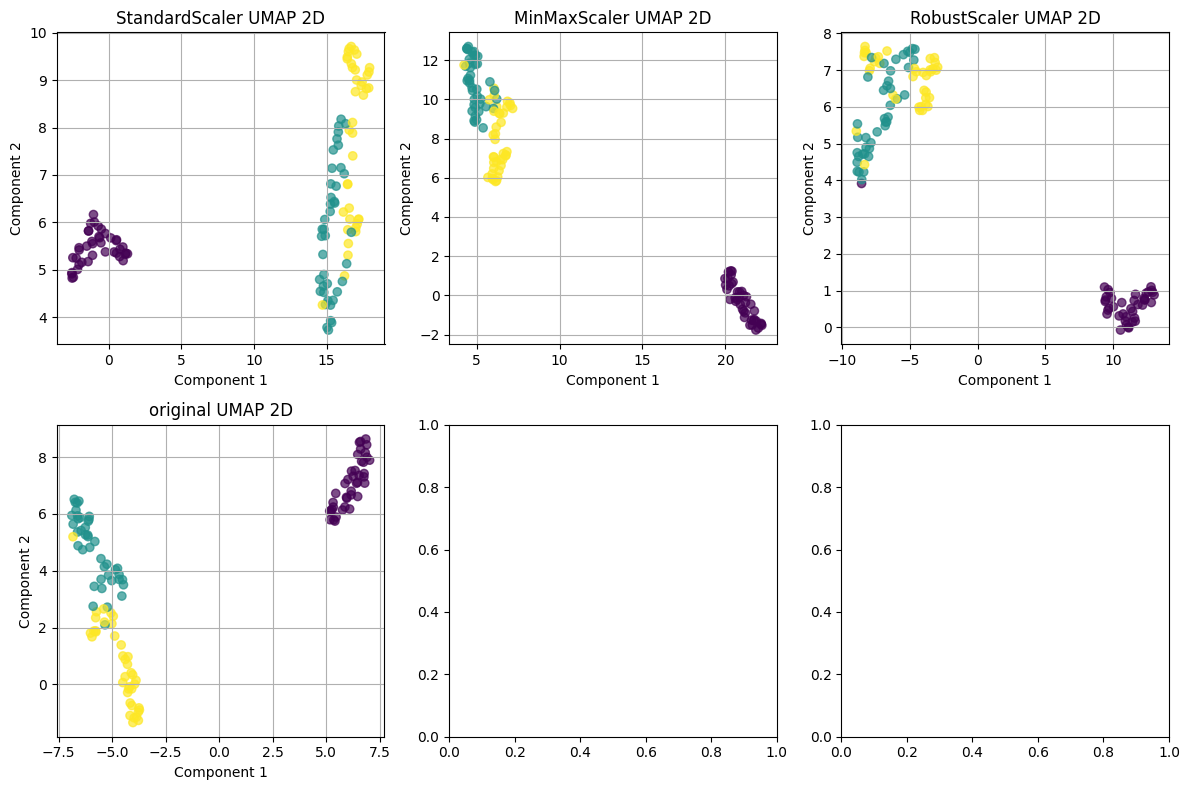

In [26]:
from umap import UMAP

for name, evaluator in evaluators.items():
    umap_reducer = UMAP(n_components=2, random_state=42)
    X_train_umap_2d = umap_reducer.fit_transform(evaluator.X_train)
    X_test_umap_2d = umap_reducer.transform(evaluator.X_test)
    reductions[name]['UMAP_2d'] = (X_train_umap_2d, X_test_umap_2d)

plot_2d_projection_comparison([(reductions[name]['UMAP_2d'][0], f"{name} UMAP 2D") for name in reductions], y=evaluator.y_train)

In [28]:
for name, evaluator in evaluators.items():
    kmeans_results[f'UMAP_2d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['UMAP_2d'])
    logistic_regression_results[f'UMAP_2d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['UMAP_2d'])
    trustworthiness_results[f'UMAP_2d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['UMAP_2d'][0], n_neighbors=5)
    knn_results[f'UMAP_2d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['UMAP_2d'])

In [135]:
for name, evaluator in evaluators.items():
    umap_reducer_3d = UMAP(n_components=3, random_state=42)
    X_train_umap_3d = umap_reducer_3d.fit_transform(evaluator.X_train)
    X_test_umap_3d = umap_reducer_3d.transform(evaluator.X_test)
    reductions[name]['UMAP_3d'] = (X_train_umap_3d, X_test_umap_3d)
    plot_3d_interactive(X_train_umap_3d, evaluator.y_train, title=f"{name} UMAP 3D")

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [92]:
for name, evaluator in evaluators.items():
    kmeans_results[f"UMAP_3d_{name}"] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['UMAP_3d'])
    logistic_regression_results[f"UMAP_3d_{name}"] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['UMAP_3d'])
    trustworthiness_results[f"UMAP_3d_{name}"] = trustworthiness(evaluator.X_train, reductions[name]['UMAP_3d'][0], n_neighbors=5)
    knn_results[f"UMAP_3d_{name}"] = evaluator._evaluate_knn_classification(*reductions[name]['UMAP_3d'])

# IsoMap

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/michalkrajewski/PythonPro

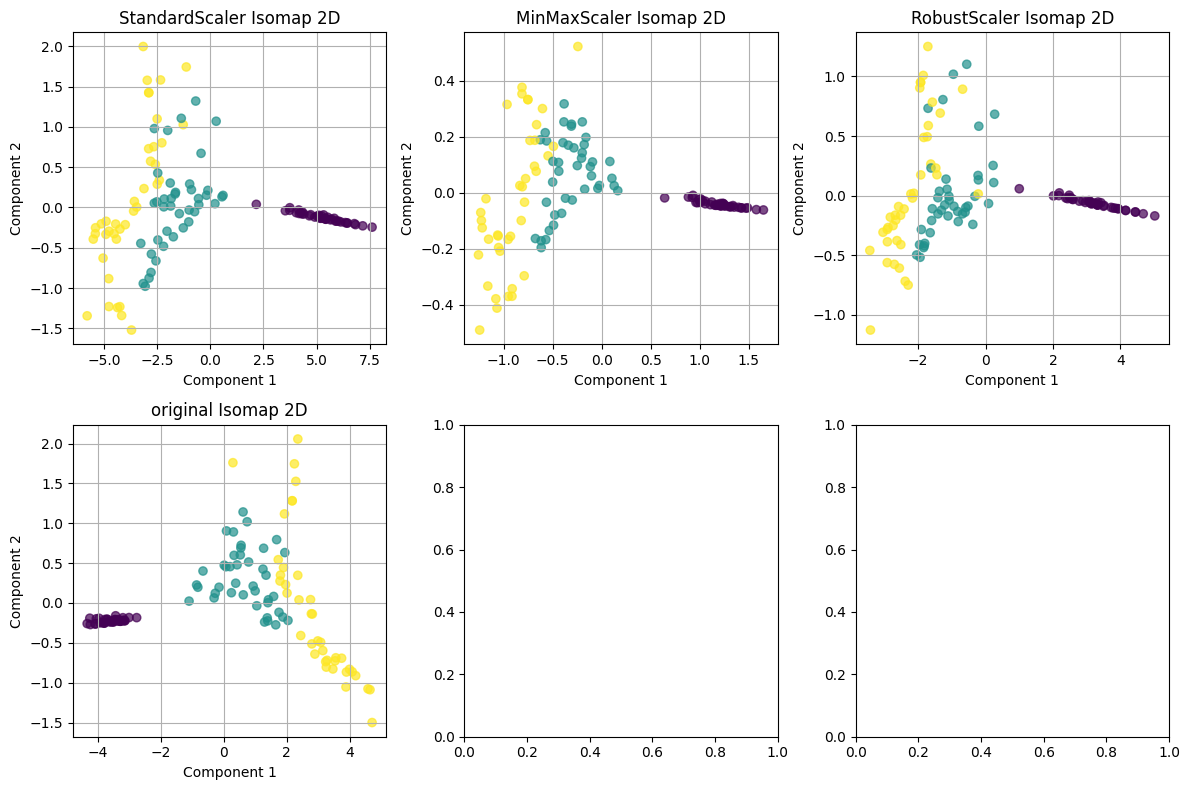

In [34]:
from sklearn.manifold import Isomap
for name, evaluator in evaluators.items():
    iso_reducer = Isomap(n_components=2, n_neighbors=5)
    X_train_iso_2d = iso_reducer.fit_transform(evaluator.X_train)
    X_test_iso_2d = iso_reducer.transform(evaluator.X_test)
    reductions[name]['Isomap_2d'] = (X_train_iso_2d, X_test_iso_2d)
plot_2d_projection_comparison([(reductions[name]['Isomap_2d'][0], f"{name} Isomap 2D") for name in reductions], y=evaluator.y_train)

In [36]:
for name, evaluator in evaluators.items():
    kmeans_results[f'Isomap_2d_{name}'] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['Isomap_2d'])
    logistic_regression_results[f'Isomap_2d_{name}'] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['Isomap_2d'])
    trustworthiness_results[f'Isomap_2d_{name}'] = trustworthiness(evaluator.X_train, reductions[name]['Isomap_2d'][0], n_neighbors=5)
    knn_results[f'Isomap_2d_{name}'] = evaluator._evaluate_knn_classification(*reductions[name]['Isomap_2d'])

In [136]:
for name, evaluator in evaluators.items():
    Iso_reducer_3d = Isomap(n_components=3, n_neighbors=5)
    X_train_iso_3d = Iso_reducer_3d.fit_transform(evaluator.X_train)
    X_test_iso_3d = Iso_reducer_3d.transform(evaluator.X_test)
    reductions[name]['Isomap_3d'] = (X_train_iso_3d, X_test_iso_3d)
    plot_3d_interactive(X_train_iso_3d, evaluator.y_train, title=f"{name} Isomap 3D")

/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/sklearn/manifold/_isomap.py:386: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/michalkrajewski/PythonProjects/Dimensionality_Reduction/.venv/lib/python3.14/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [52]:
for name, evaluator in evaluators.items():
    kmeans_results[f"Isomap_3d_{name}"] = evaluator._evaluate_reduction_with_kmeans(*reductions[name]['Isomap_3d'])
    logistic_regression_results[f"Isomap_3d_{name}"] = evaluator.predict_on_reduced_with_logistic_regression(*reductions[name]['Isomap_3d'])
    trustworthiness_results[f"Isomap_3d_{name}"] = trustworthiness(evaluator.X_train, reductions[name]['Isomap_3d'][0], n_neighbors=5)
    knn_results[f"Isomap_3d_{name}"] = evaluator._evaluate_knn_classification(*reductions[name]['Isomap_3d'])

In [ ]:
def plot_embedding(embedding, labels, title="", ax=None):

    """Rysuje embedding 2D, kolorując punkty wg etykiet."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(title)
    ax.grid(True, which="major", linewidth=0.5, color="gray", alpha=0.5)

In [ ]:
X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

neighbor_values = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

iso_scores, umap_scores = [], []
for k in neighbor_values:
    emb_iso = iso(X_scaled, n_neighbors=k, scale=False)
    emb_umap = UMAP(n_components=2, random_state=42)
    emb_umap = emb_umap.fit_transform(X_scaled)
    iso_scores.append(trustworthiness(X_scaled, emb_iso))
    umap_scores.append(trustworthiness(X_scaled, emb_umap))


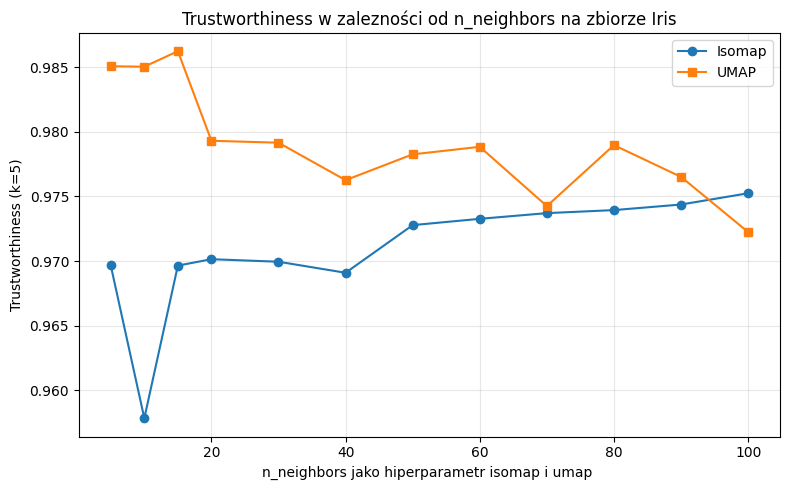

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(neighbor_values, iso_scores, "o-", label="Isomap")
plt.plot(neighbor_values, umap_scores, "s-", label="UMAP")
plt.xlabel("n_neighbors jako hiperparametr isomap i umap ")
plt.ylabel(f"Trustworthiness")
plt.title("Trustworthiness w zalezności od n_neighbors na zbiorze Iris")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
)
from utils.isomap_umap import isomap, umap_reduce

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)
n_clusters = len(np.unique(y))

neighbor_values = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

metrics = ["NMI", "Silhouette", "Calinski-Harabasz"]
results = {m: {"isomap": [], "umap": []} for m in metrics}


In [ ]:
for k in neighbor_values:
    for name, fn in [("isomap", isomap), ("umap", umap_reduce)]:
        emb = fn(X_scaled, n_neighbors=k, scale=False)
        km = KMeans(n_clusters=n_clusters, random_state=1, n_init=10).fit_predict(emb)

        results["NMI"][name].append(normalized_mutual_info_score(y, km))
        results["Silhouette"][name].append(silhouette_score(emb, y))
        results["Calinski-Harabasz"][name].append(calinski_harabasz_score(emb, y))



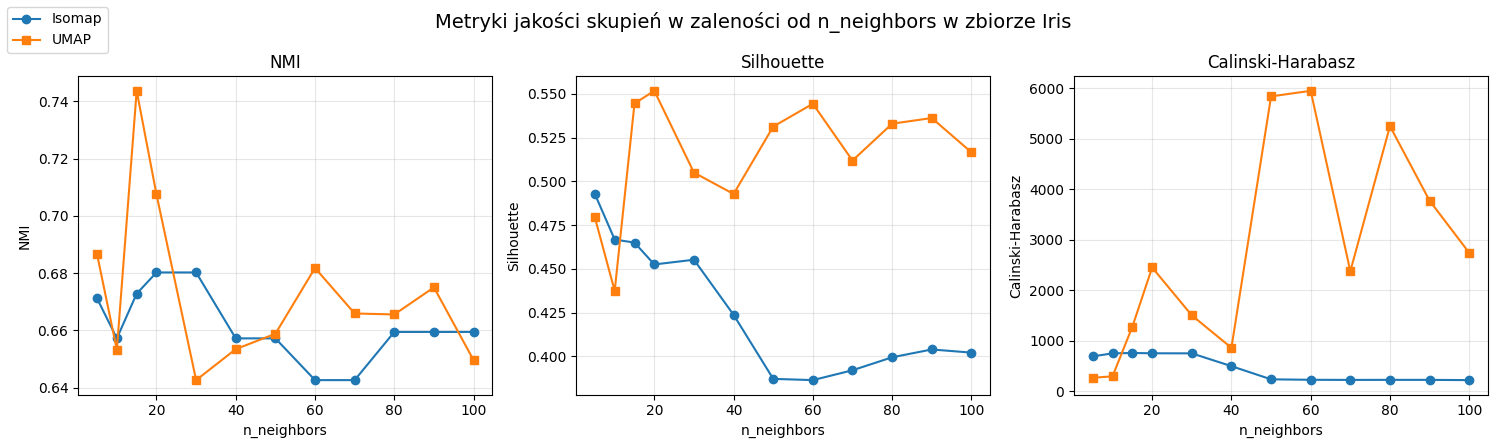

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, metrics):
    ax.plot(neighbor_values, results[metric]["isomap"], "o-", label="Isomap")
    ax.plot(neighbor_values, results[metric]["umap"], "s-", label="UMAP")
    ax.set_title(metric)
    ax.set_xlabel("n_neighbors")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=1)

fig.suptitle("Metryki jakości skupień w zaleności od n_neighbors w zbiorze Iris", fontsize=14)
fig.tight_layout()
plt.show()

(<Figure size 600x400 with 2 Axes>,
 <Axes: title={'center': 't-SNE 2D'}, xlabel='Component 1', ylabel='Component 2'>)

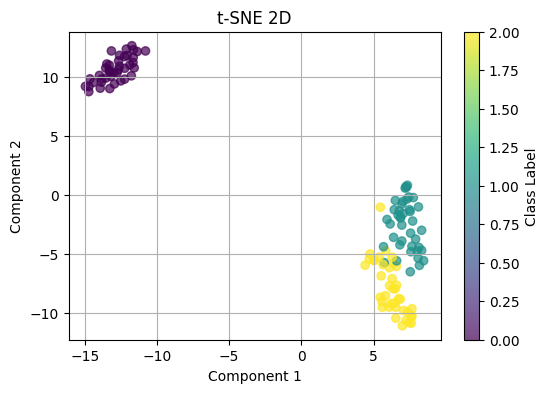

In [64]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(evaluator.X_train)
plot_2d_projection(X_tsne, evaluator.y_train, title="t-SNE 2D")

In [137]:
tsne_3d = TSNE(n_components=3, random_state=42)
X_tsne_3d = tsne_3d.fit_transform(evaluator.X_train)
plot_3d_interactive(X_tsne_3d, evaluator.y_train, title="t-SNE 3D")

# Omówienie wyników

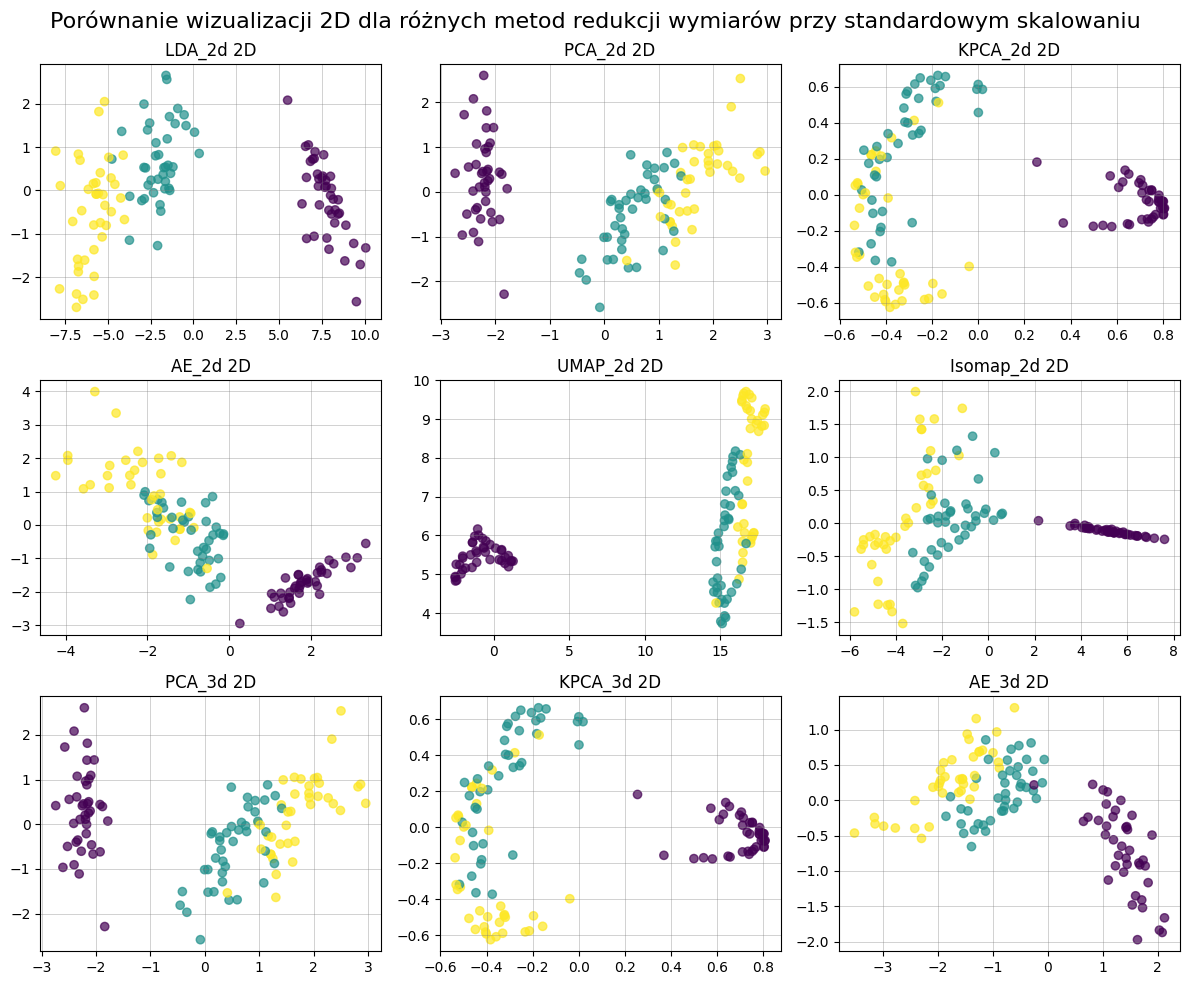

In [90]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
fig.suptitle("Porównanie wizualizacji 2D dla różnych metod redukcji wymiarów przy standardowym skalowaniu", fontsize=16)
for ax, name in zip(axes.flatten(), ['LDA_2d', 'PCA_2d', 'KPCA_2d', 'AE_2d', 'UMAP_2d', 'Isomap_2d', 'PCA_3d', 'KPCA_3d', 'AE_3d']):
    ax.scatter(reductions['StandardScaler'][f'{name}'][0][:, 0], reductions['StandardScaler'][f'{name}'][0][:, 1], c=evaluator.y_train, cmap="viridis", alpha=0.7)
    ax.set_title(f"{name} 2D")
    ax.grid(True, which="major", linewidth=0.5, color="gray", alpha=0.5)

plt.tight_layout()

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71974/3031605604.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['LDA_2d', 'PCA_2d', 'KPCA_2d', 'AE_2d', 'UMAP_2d', 'Isomap_2d'], rotation=2, ha='right')
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71974/3031605604.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['LDA_2d', 'PCA_2d', 'KPCA_2d', 'AE_2d', 'UMAP_2d', 'Isomap_2d'], rotation=2, ha='right')
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71974/3031605604.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['LDA_2d', 'PCA_2d', 'KPCA_2d', 'AE_2d', 'UMAP_2d', 'Isomap_2d'], rotation=2, ha='right')
/var/folders/9f/vftxvqkj6f9817yp5q

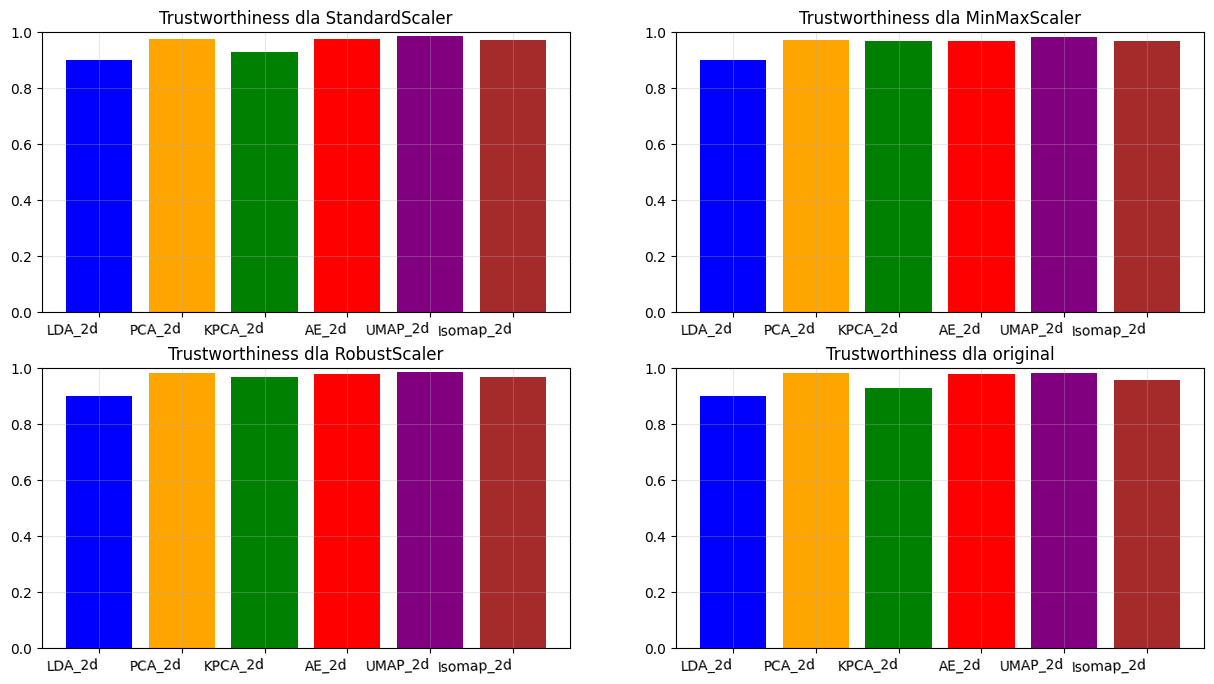

In [72]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, name in zip(axes.flatten(), reductions.keys()):
    ax.bar(['LDA_2d', 'PCA_2d', 'KPCA_2d', 'AE_2d', 'UMAP_2d', 'Isomap_2d'],
           [trustworthiness_results.get(f'LDA_2d', 0),
            trustworthiness_results.get(f'PCA_2d_{name}', 0),
            trustworthiness_results.get(f'KPCA_2d_{name}', 0),
            trustworthiness_results.get(f'AE_2d_{name}', 0),
            trustworthiness_results.get(f'UMAP_2d_{name}', 0),
            trustworthiness_results.get(f'Isomap_2d_{name}', 0)],
           color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
    ax.set_title(f"Trustworthiness dla {name}")
    ax.set_ylim(0, 1)
    ax.set_xticklabels(['LDA_2d', 'PCA_2d', 'KPCA_2d', 'AE_2d', 'UMAP_2d', 'Isomap_2d'], rotation=2, ha='right')
    ax.grid(True, alpha=0.3)



In [74]:
trustworthiness_results['PCA_3d_original']

np.float64(0.9969196428571429)

In [75]:
reductions.keys()

dict_keys(['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'original'])

/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71974/1089021468.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ 'PCA_3d', 'KPCA_3d', 'AE_3d', 'UMAP_3d', 'Isomap_3d'], rotation=2, ha='right')
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71974/1089021468.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ 'PCA_3d', 'KPCA_3d', 'AE_3d', 'UMAP_3d', 'Isomap_3d'], rotation=2, ha='right')
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71974/1089021468.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([ 'PCA_3d', 'KPCA_3d', 'AE_3d', 'UMAP_3d', 'Isomap_3d'], rotation=2, ha='right')
/var/folders/9f/vftxvqkj6f9817yp5q44s5b80000gn/T/ipykernel_71

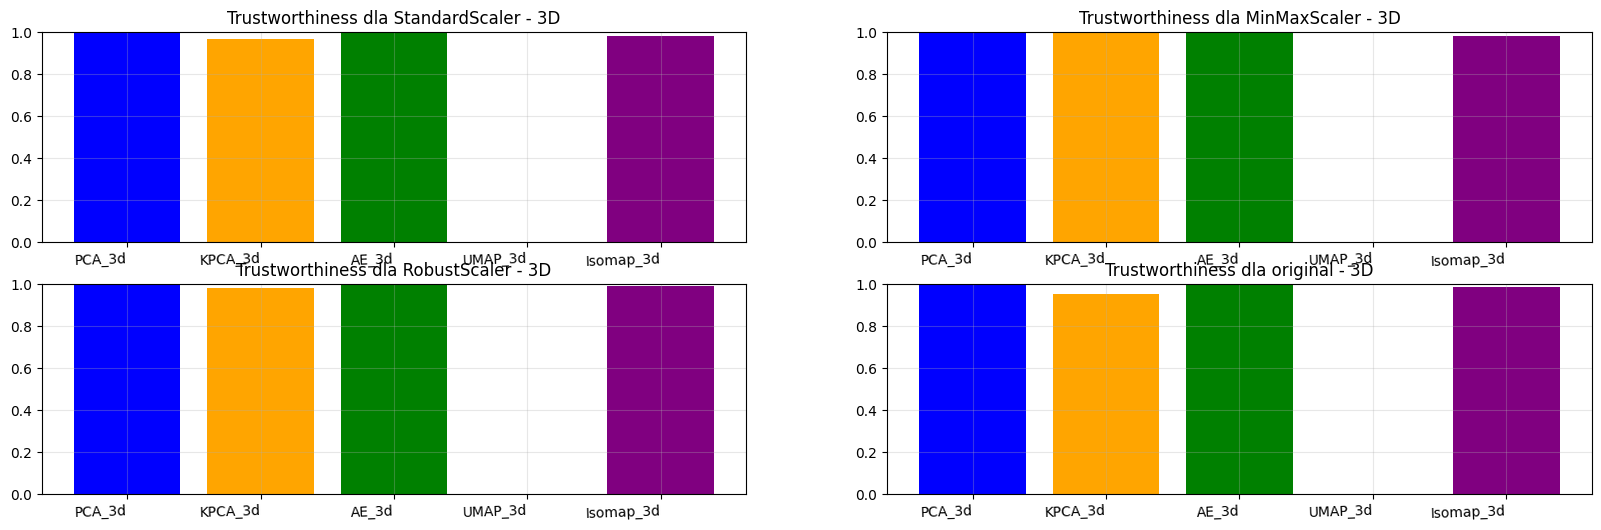

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(20, 6))
for ax, name in zip(axes.flatten(), reductions.keys()):
    ax.bar([ 'PCA_3d', 'KPCA_3d', 'AE_3d', 'UMAP_3d', 'Isomap_3d'],
           [trustworthiness_results.get(f'PCA_3d_{name}', 0),
            trustworthiness_results.get(f'KPCA_3d_{name}', 0),
            trustworthiness_results.get(f'AE_3d_{name}', 0),
            trustworthiness_results.get(f'UMAP_3d_{name}', 0),
            trustworthiness_results.get(f'Isomap_3d_{name}', 0)],
           color=['blue', 'orange', 'green', 'red', 'purple', 'brown'])
    ax.set_title(f"Trustworthiness dla {name} - 3D")
    ax.set_ylim(0, 1)
    ax.set_xticklabels([ 'PCA_3d', 'KPCA_3d', 'AE_3d', 'UMAP_3d', 'Isomap_3d'], rotation=2, ha='right')
    ax.grid(True, alpha=0.3)


# Zastosowania w klasyfikacji 

Regresja logistyczna

In [56]:
from sklearn.metrics import accuracy_score, f1_score
accuracies = {}
f1_scores = {}
for name, y_pred in logistic_regression_results.items():
    accuracy = accuracy_score(evaluator.y_test, y_pred)
    f1 = f1_score(evaluator.y_test, y_pred, average='weighted')
    accuracies[name] = accuracy
    f1_scores[name] = f1

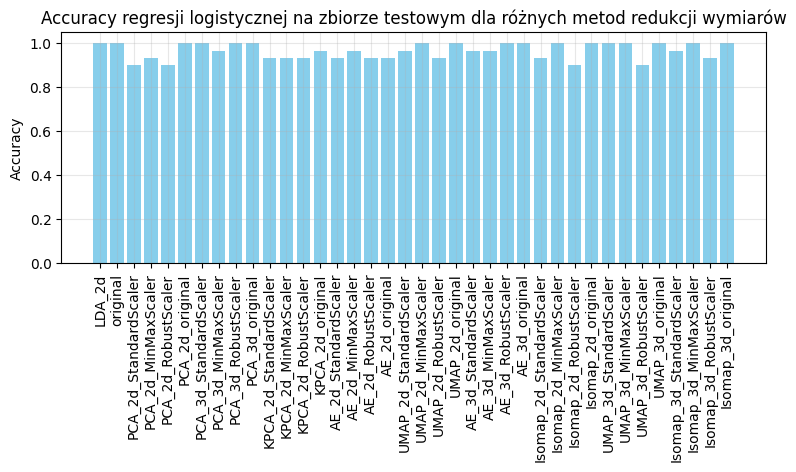

In [66]:
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Accuracy')
plt.title('Accuracy regresji logistycznej na zbiorze testowym dla różnych metod redukcji wymiarów')
plt.grid(True, alpha=0.3)   

KNN

In [93]:
accuracy_values = {}
f1_scores = {}
for name, y_pred in knn_results.items():
    accuracy = accuracy_score(evaluator.y_test, y_pred)
    f1 = f1_score(evaluator.y_test, y_pred, average='weighted')
    accuracy_values[name] = accuracy
    f1_scores[name] = f1   

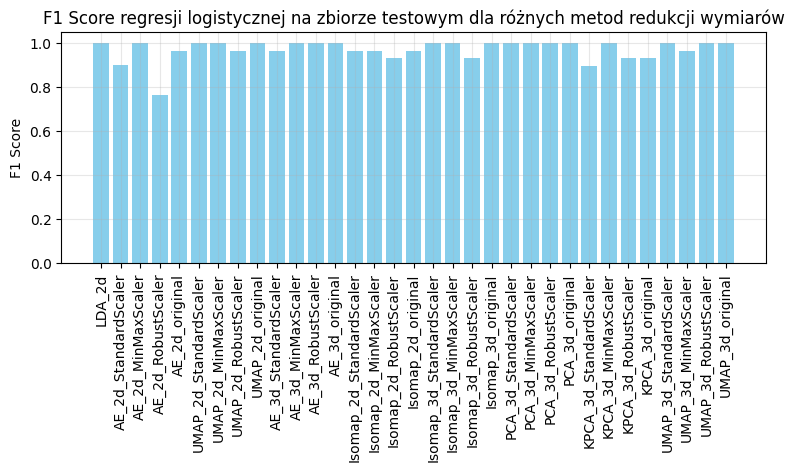

In [95]:
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.bar(f1_scores.keys(), f1_scores.values(), color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('F1 Score')
plt.title('F1 Score regresji logistycznej na zbiorze testowym dla różnych metod redukcji wymiarów')
plt.grid(True, alpha=0.3)   

In [97]:
ari_values = {}
nmi_values = {}
for name, vals in kmeans_results.items():
    ari_values[name] = vals['train_ARI']
    nmi_values[name] = vals['train_NMI']
    

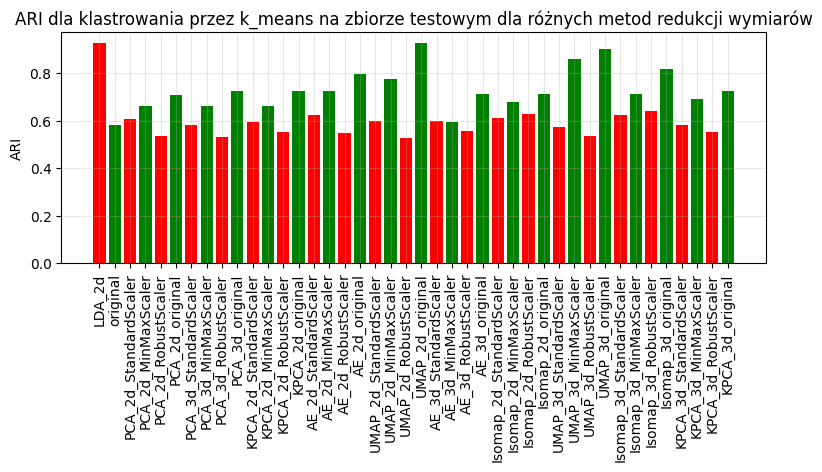

In [111]:
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.bar(ari_values.keys(), ari_values.values(), color = [('red', 'green')[i % 2] for i, key in enumerate(ari_values.keys())])
plt.xticks(rotation=90)
plt.ylabel('ARI')
plt.title('ARI dla klastrowania przez k_means na zbiorze testowym dla różnych metod redukcji wymiarów')
plt.grid(True, alpha=0.3)   

In [101]:
only_standar_scaled = {key: value for key, value in logistic_regression_results.items() if 'StandardScaler' in key}
only_standar_scaled

{'PCA_2d_StandardScaler': array([1, 0, 2, 1, 2, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 1,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'PCA_3d_StandardScaler': array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'KPCA_2d_StandardScaler': array([1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'AE_2d_StandardScaler': array([1, 0, 2, 1, 2, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 1,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'UMAP_2d_StandardScaler': array([1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'AE_3d_StandardScaler': array([1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'Isomap_2d_StandardScaler': array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 2, 2, 1, 1, 2, 0, 1,
        0, 2, 2, 2, 2, 2, 0, 0]),
 'UMAP_3d_StandardScaler': array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2,